# Generate data from rate model

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

import pickle as pk

2025-10-15 16:22:25.962130: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-15 16:22:25.971011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-15 16:22:25.980656: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-15 16:22:25.983446: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-15 16:22:25.991459: I tensorflow/core/platform/cpu_feature_guar

### check trained models

In [2]:
# jitter models trained without LFP input

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0'

lfp_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '4.0', '.mat'])
# remove directories
lfp_model_list = [m.split('/')[-1] for m in lfp_model_list]
lfp_model_list.sort()

print(lfp_model_list)
print(len(lfp_model_list))


['Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135226.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135856.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141842.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726.mat', 'Task_xor

In [4]:
# remove models that did not train properly

import os
for i, model_name in enumerate(lfp_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs = model_data['eval_perf_mean'][0][0]
    if perfs < 0.95:
        print(f'removing {model_name} with perf {perfs}')
        # os.remove(model_path)

In [6]:
model_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in_stim0', 'w_in_lfp0', 'u', 'o', 'w', 'x', 'target', 'lfp_power_target', 'power_target_period', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in_stim', 'w_in_lfp', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'jitter_onset', 'jitter_delay', 'train_settings', 'tr', 'activation', 'all_perfs', 'opt_scaling_factor', 'scaling_factors', 'all_perfs_new', 'opt_scaling_factor_new'])

Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255.mat, Test perf: 0.99, Train trials: 4801
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527.mat, Test perf: 0.97, Train trials: 7201
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559.mat, Test perf: 0.99, Train trials: 10201
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903.mat, Test perf: 0.96, Train trials: 11001
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100.mat, Test perf: 0.99, Train trials: 5001
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135226.mat, Test perf: 0.97, Train trials: 5801
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135856.mat, Test perf: 1.0, Train trials: 7201
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038.mat, Test perf: 0.98, Train trials: 10501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105.mat, Test perf: 0.99, Train trials: 7901
Model: Task_xor_N_200_Jitter_10_10_

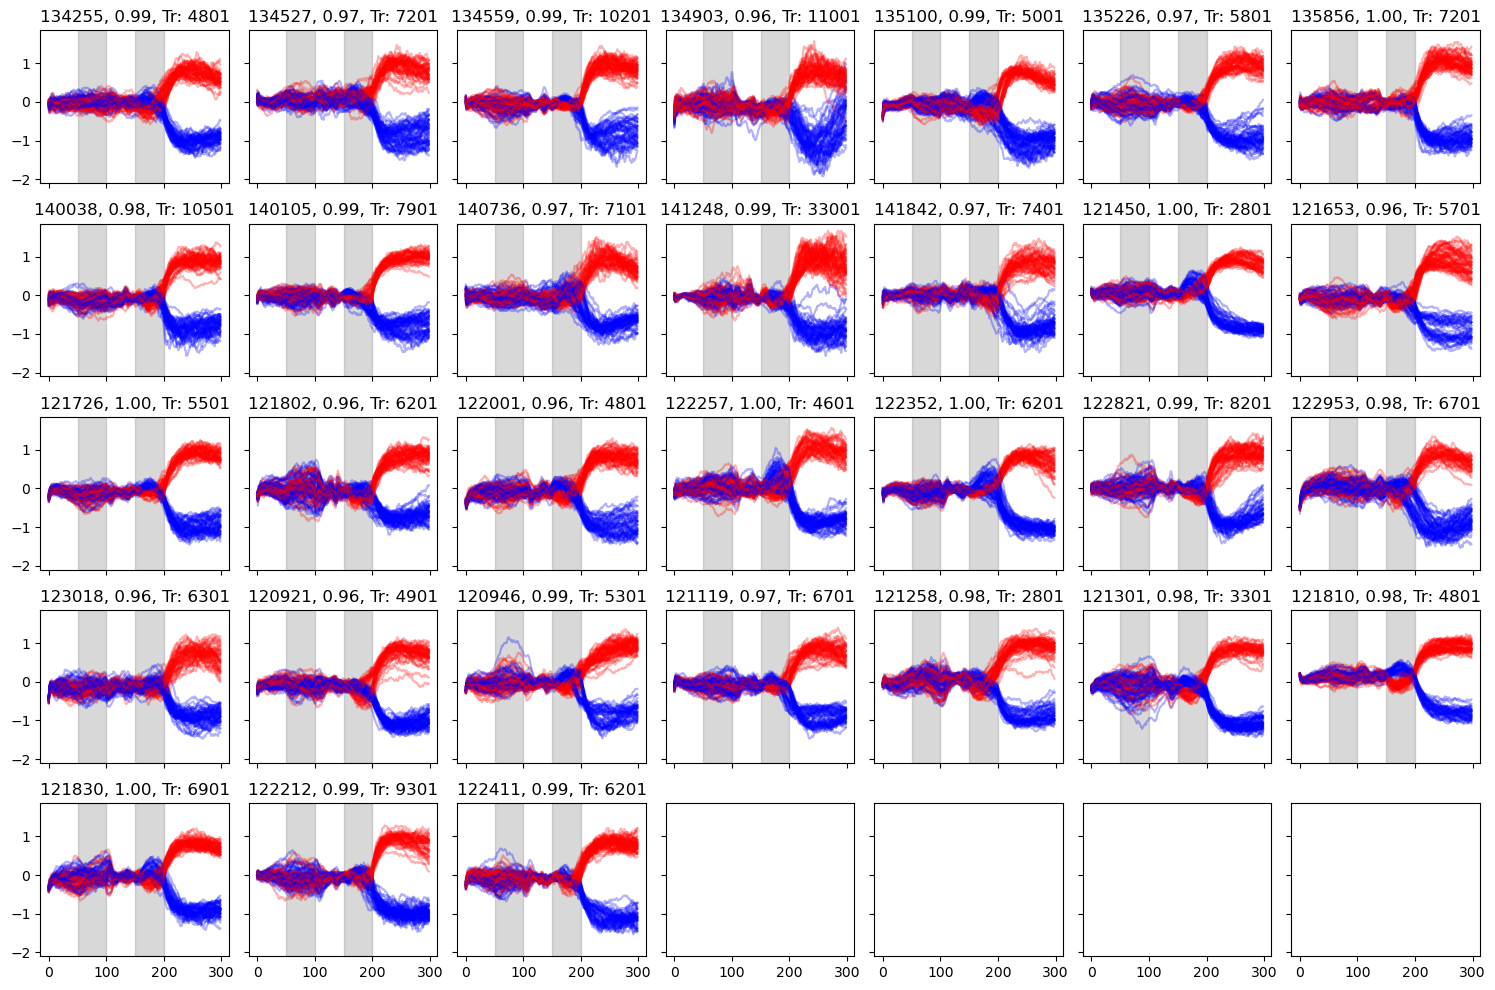

In [3]:
fig, axs = plt.subplots(5, 7, figsize=(15,10), sharex=True, sharey=True)
axs = axs.flatten()

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')
    
    stim1_on = 50
    stim1_off = stim1_on + 50
    stim2_on = stim1_off + 50
    stim2_off = stim2_on + 50

    outs = model_data['eval_os']
    labels = model_data['eval_labels']
    c = ['r' if labels[j]=='same' else 'b' for j in range(len(labels))]
    # c = [0 if labels[j]=='same' else 1 for j in range(len(labels))]
    for j in range(outs.shape[0]):
        axs[i].plot(outs[j].T, color=c[j], alpha=0.3)
    # axs[i].plot(outs.T, color=c, alpha=0.3)
    axs[i].set_title(f'{model_name[-10:-4]}, {perfs[i]:.2f}, Tr: {train_trials[i]}')
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

## generate data for longer delay (400)

In [4]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_LFP_input_phase

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [6]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# not parallelized

n_trials = 25
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_model_list

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay'] + 10


for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': [],
        'outputs': [],
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)
        
    with open(os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(settings, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [7]:
n_trials = 25
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_model_list

In [10]:
import os
import numpy as np
import pickle as pk
from concurrent.futures import ProcessPoolExecutor

def process_model(model_name):
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')
    settings_path = os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl')

    if os.path.exists(neural_path) and os.path.exists(bhv_path) and os.path.exists(settings_path):
        print(f"Skipping {model_name}, already saved.")
        return

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for stim1 in stim1s:
        for stim2 in stim2s:
            for _ in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]

                _, r, o, epsp = model.eval_tf(
                    model_dir=os.path.join(model_dir, model_name),
                    settings=settings,
                    u=u,
                    calc_epsp=True
                )

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                if label == 'same':
                    bhv_dict['perf'].append(int(np.max(o[resp_onset:]) > eval_amp_threshold))
                else:
                    bhv_dict['perf'].append(int(np.min(o[resp_onset:]) < -eval_amp_threshold))

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)
    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)
    with open(settings_path, 'wb') as f:
        pk.dump(settings, f)

    print(f"✔ Saved model outputs to {output_dir}")

# ---- MAIN EXEC ----
if __name__ == '__main__':
    n_trials = 25
    eval_amp_threshold = 0.7
    stim1s = [-1, 1]
    stim2s = [-1, 1]
    model_dir = lfp_model_dir
    model_list = lfp_model_list

    settings = {
        'T': 650,
        'stim_on': 50,
        'stim_dur': 50,
        'delay': 400,
        'DeltaT': 1,
        'taus': 20,
        'lfp_power_target': [4],
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor',
    }

    resp_onset = settings['stim_on'] + 2 * settings['stim_dur'] + settings['delay'] + 10

    with ProcessPoolExecutor() as executor:
        executor.map(process_model, model_list)


✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122257
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/x

### make some quick behavior plots

In [11]:
colors = ['#6E439A', '#2B1644', '#236975', '#49BEA3']

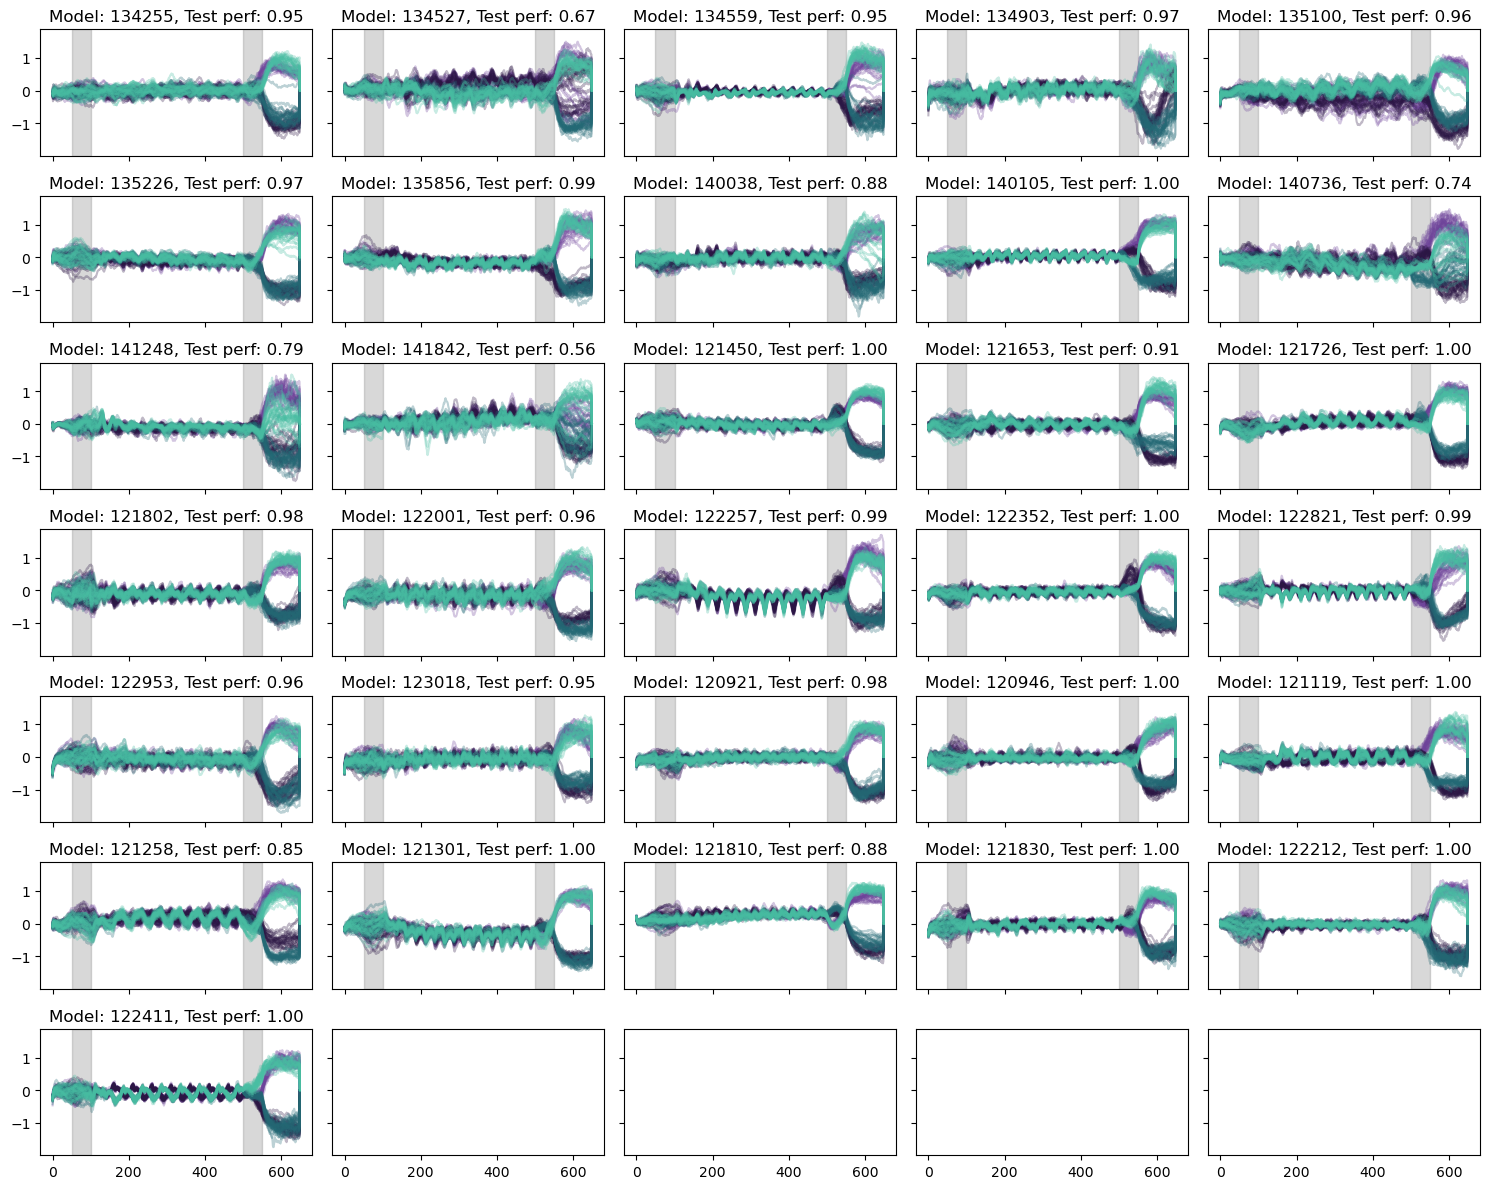

In [13]:
# plot output for each model

fig, axs = plt.subplots(7,5, figsize=(15,12), sharex=True, sharey=True)
axs = axs.flatten()
test_perfs = []
for i, model_name in enumerate(lfp_model_list):
    output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    with open(os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl'), 'rb') as f:
        settings = pk.load(f)
    
    for n in range(len(bhv_dict['outputs'])):
        axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][0] == 1) * 2 + int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
    axs[i].set_title(f'Model: {model_name[-10:-4]}, Test perf: {np.mean(bhv_dict["perf"]):.2f}')
    test_perfs.append(np.mean(bhv_dict['perf']))
    stim1_on = settings['stim_on']
    stim1_off = stim1_on + settings['stim_dur']
    stim2_on = stim1_off + settings['delay']
    stim2_off = stim2_on + settings['stim_dur']
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

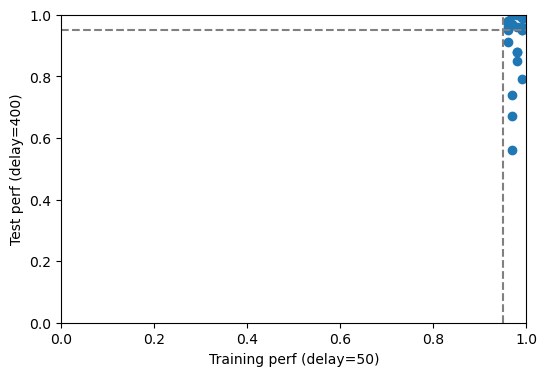

In [14]:
# plot behavior 
plt.figure(figsize=(6,4))
plt.scatter(perfs, test_perfs)
plt.axvline(x=0.95, color='gray', linestyle='--')
plt.axhline(y=0.95, color='gray', linestyle='--')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Training perf (delay=50)')
plt.ylabel('Test perf (delay=400)')
plt.show()


## no LFP input to exc units

In [4]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_LFP_input_phase

Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [6]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# not parallelized

# for LFP models; lesion exc LFP inputs -- ie only inh get sine inputs; theta=4.0

import importlib
importlib.reload(model)

lesion_type = 'lfp_exc'
lesion_perc = 0

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')) and \
        os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                # _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)
                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, 
                                              u=u, lesion=lesion_type, lesion_perc=lesion_perc*0.01, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [7]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# Settings
lesion_type = 'lfp_exc'
lesion_perc = 0
n_trials = 25
resp_onset = settings['stim_on'] + 2 * settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1, 1]
stim2s = [-1, 1]
model_dir = lfp_model_dir
model_list = lfp_model_list

def run_model(model_name):
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')

    # if os.path.exists(neural_path) and os.path.exists(bhv_path):
    #     print(f'Skipping {model_name}, already saved')
    #     return f'Skipped {model_name}'

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for stim1 in stim1s:
        for stim2 in stim2s:
            for _ in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]

                _, r, o, epsp = model.eval_tf(
                    model_dir=os.path.join(model_dir, model_name),
                    settings=settings,
                    u=u,
                    lesion=lesion_type,
                    lesion_perc=lesion_perc * 0.01,
                    calc_epsp=True
                )

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                # Behavioral performance logic
                if label == 'same':
                    bhv_dict['perf'].append(int(np.max(o[resp_onset:]) > eval_amp_threshold))
                else:
                    bhv_dict['perf'].append(int(np.min(o[resp_onset:]) < -eval_amp_threshold))

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    # Convert to numpy
    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    # Save results
    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)

    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")
    return f"Done {model_name}"

# Run in parallel
if __name__ == '__main__':
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(run_model, model_list))
    print("All models processed.")


✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121119
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/x

### make some quick behavior plots

In [3]:
colors = ['#6E439A', '#2B1644', '#236975', '#49BEA3']

Condition: delay400_lfp_exc0


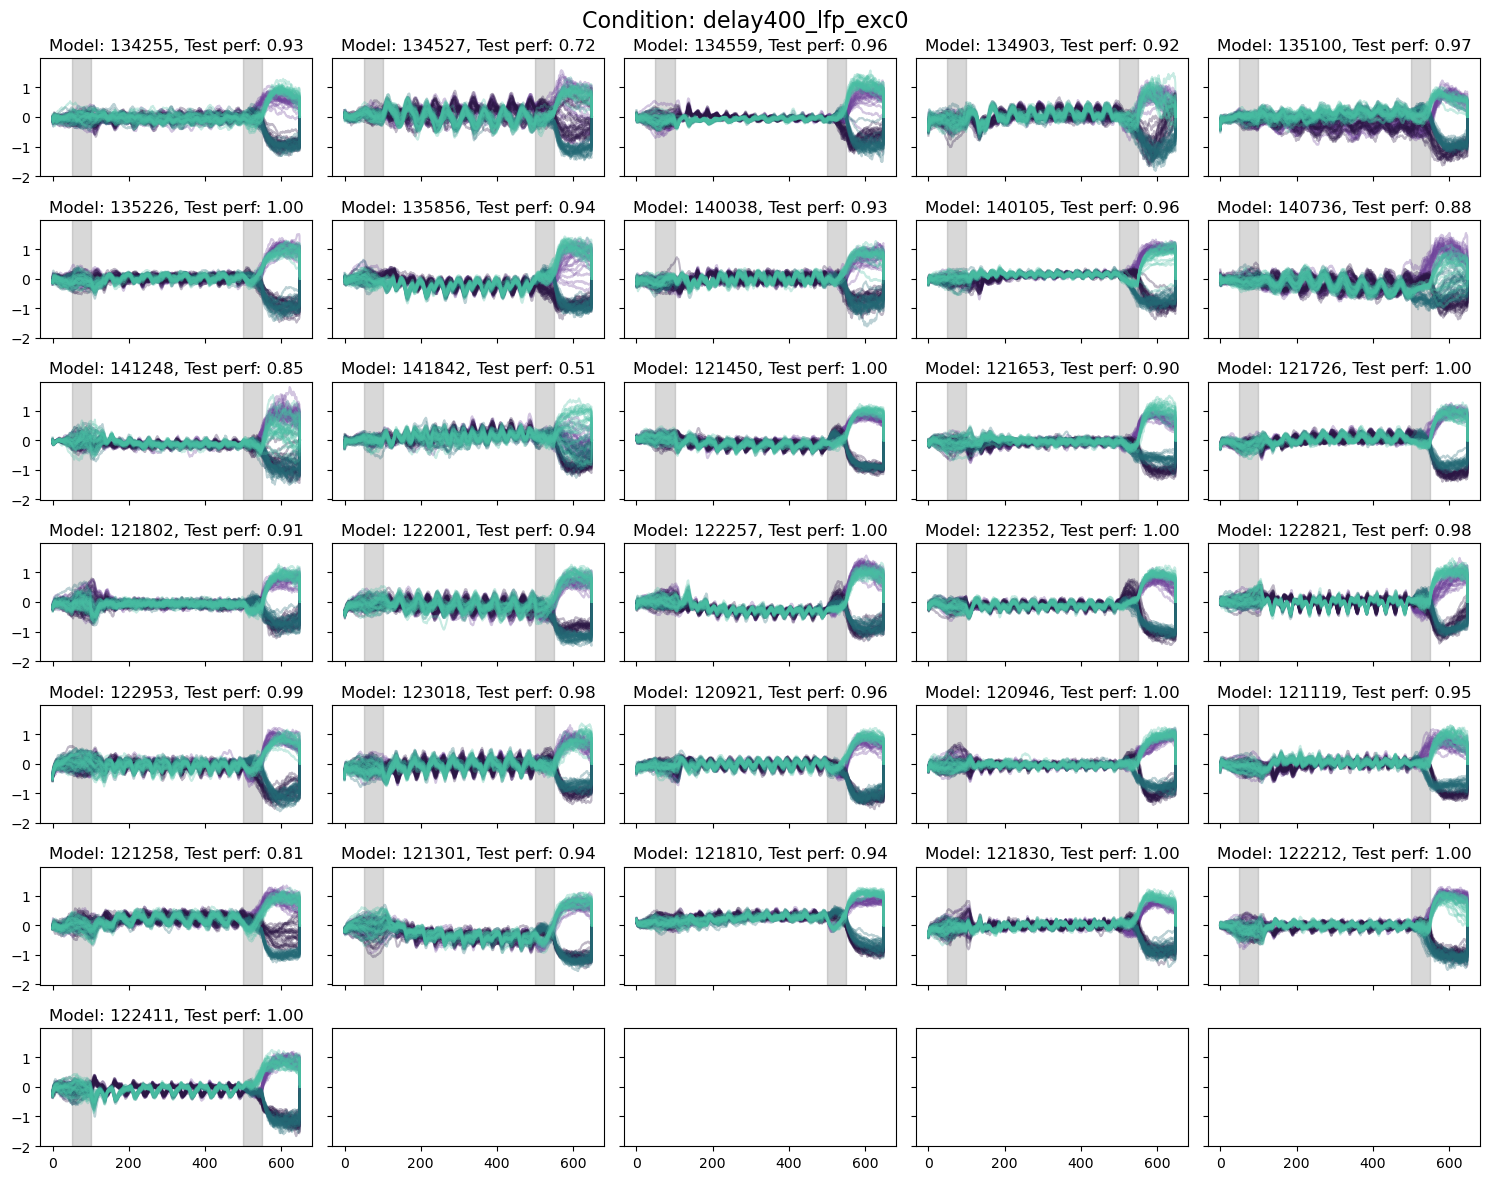

Condition: delay400_lfp_inh0


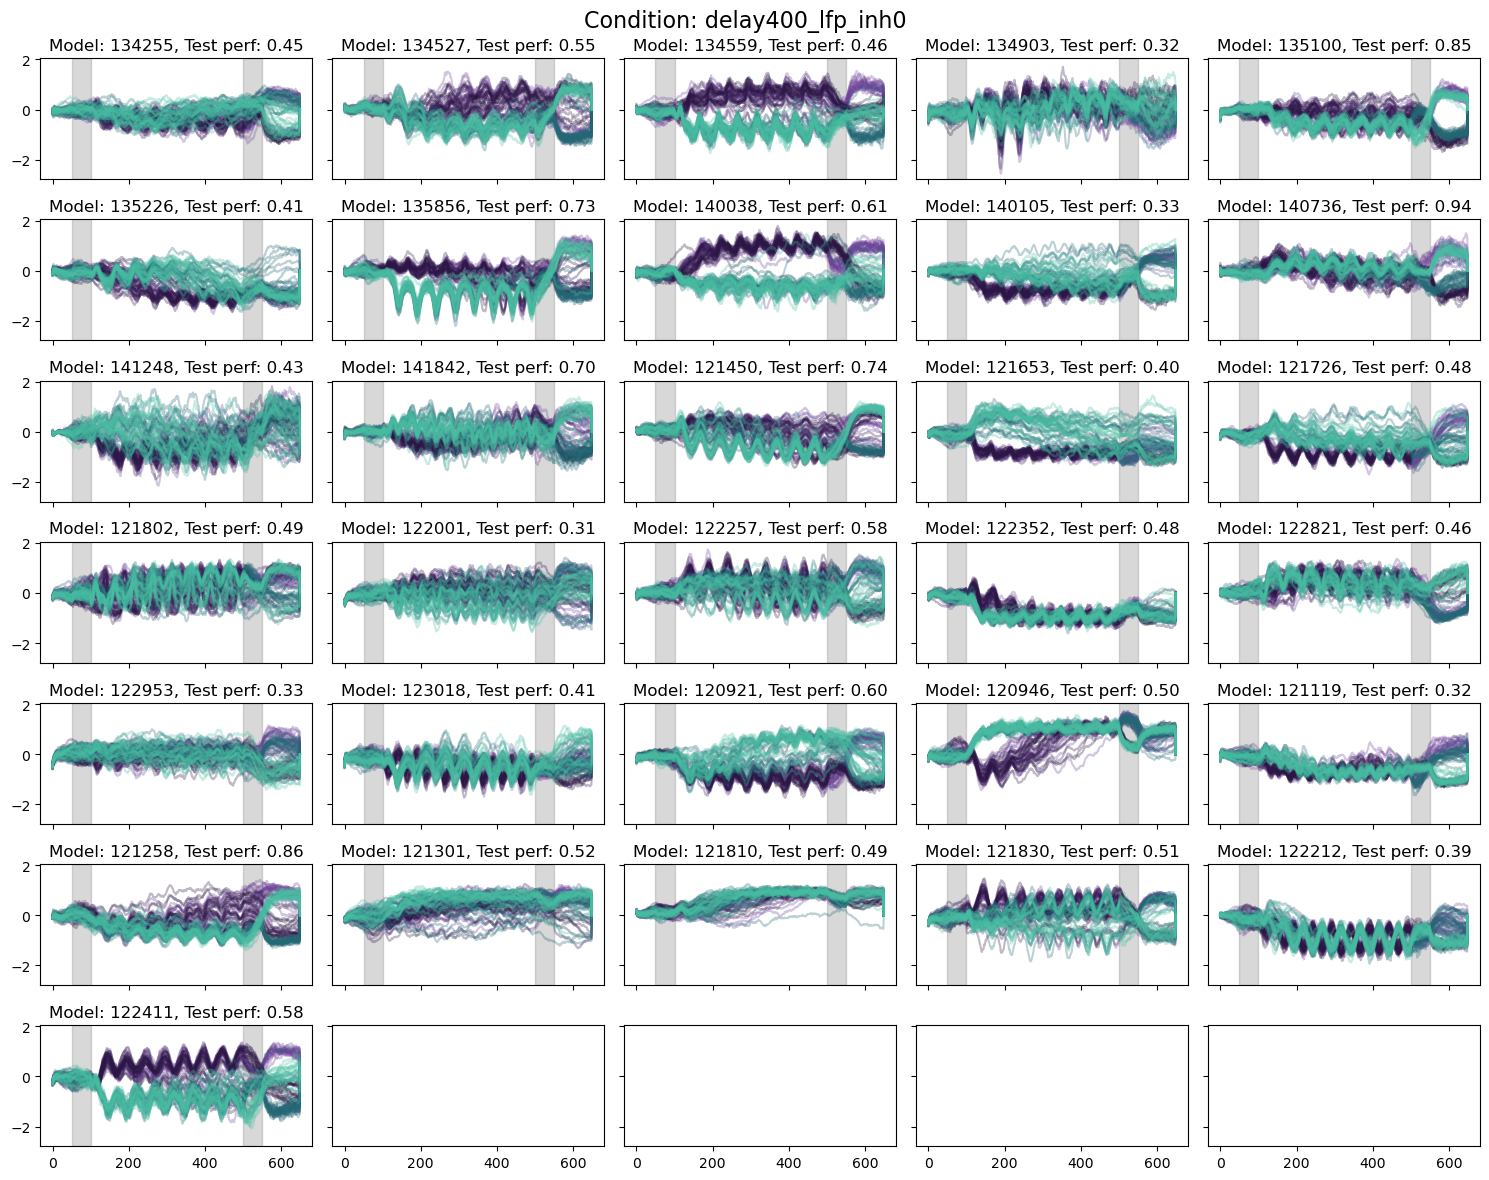

In [5]:
# plot output for each model

condns = ['delay400_lfp_exc0', 'delay400_lfp_inh0']

for condn in condns:
    print(f'Condition: {condn}')

    fig, axs = plt.subplots(7,5, figsize=(15,12), sharex=True, sharey=True)
    axs = axs.flatten()
    test_perfs = []
    for i, model_name in enumerate(lfp_model_list):
        output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
        with open(os.path.join(output_dir, f'bhv_dict_{condn}.pkl'), 'rb') as f:
            bhv_dict = pk.load(f)
        with open(os.path.join(output_dir, f'settings_delay400.pkl'), 'rb') as f:
            settings = pk.load(f)
        
        for n in range(len(bhv_dict['outputs'])):
            axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][0] == 1) * 2 + int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
        axs[i].set_title(f'Model: {model_name[-10:-4]}, Test perf: {np.mean(bhv_dict["perf"]):.2f}')
        test_perfs.append(np.mean(bhv_dict['perf']))
        stim1_on = settings['stim_on']
        stim1_off = stim1_on + settings['stim_dur']
        stim2_on = stim1_off + settings['delay']
        stim2_off = stim2_on + settings['stim_dur']
        axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
        axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)
    plt.suptitle(f'Condition: {condn}', fontsize=16)
    plt.tight_layout()
    plt.show()

## no LFP input to inh units

In [8]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# Settings
lesion_type = 'lfp_inh'
lesion_perc = 0
n_trials = 25
resp_onset = settings['stim_on'] + 2 * settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1, 1]
stim2s = [-1, 1]
model_dir = lfp_model_dir
model_list = lfp_model_list

def run_model(model_name):
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}_{lesion_type}{lesion_perc}.pkl')

    # if os.path.exists(neural_path) and os.path.exists(bhv_path):
    #     print(f'Skipping {model_name}, already saved')
    #     return f'Skipped {model_name}'

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for stim1 in stim1s:
        for stim2 in stim2s:
            for _ in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]

                _, r, o, epsp = model.eval_tf(
                    model_dir=os.path.join(model_dir, model_name),
                    settings=settings,
                    u=u,
                    lesion=lesion_type,
                    lesion_perc=lesion_perc * 0.01,
                    calc_epsp=True
                )

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                # Behavioral performance logic
                if label == 'same':
                    bhv_dict['perf'].append(int(np.max(o[resp_onset:]) > eval_amp_threshold))
                else:
                    bhv_dict['perf'].append(int(np.min(o[resp_onset:]) < -eval_amp_threshold))

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    # Convert to numpy
    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    # Save results
    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)

    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")
    return f"Done {model_name}"

# Run in parallel
if __name__ == '__main__':
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(run_model, model_list))
    print("All models processed.")


✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_123018
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_122953
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_10_10_121301
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/x

### make some quick behavior plots

In [ ]:
colors = ['#6E439A', '#2B1644', '#236975', '#49BEA3']

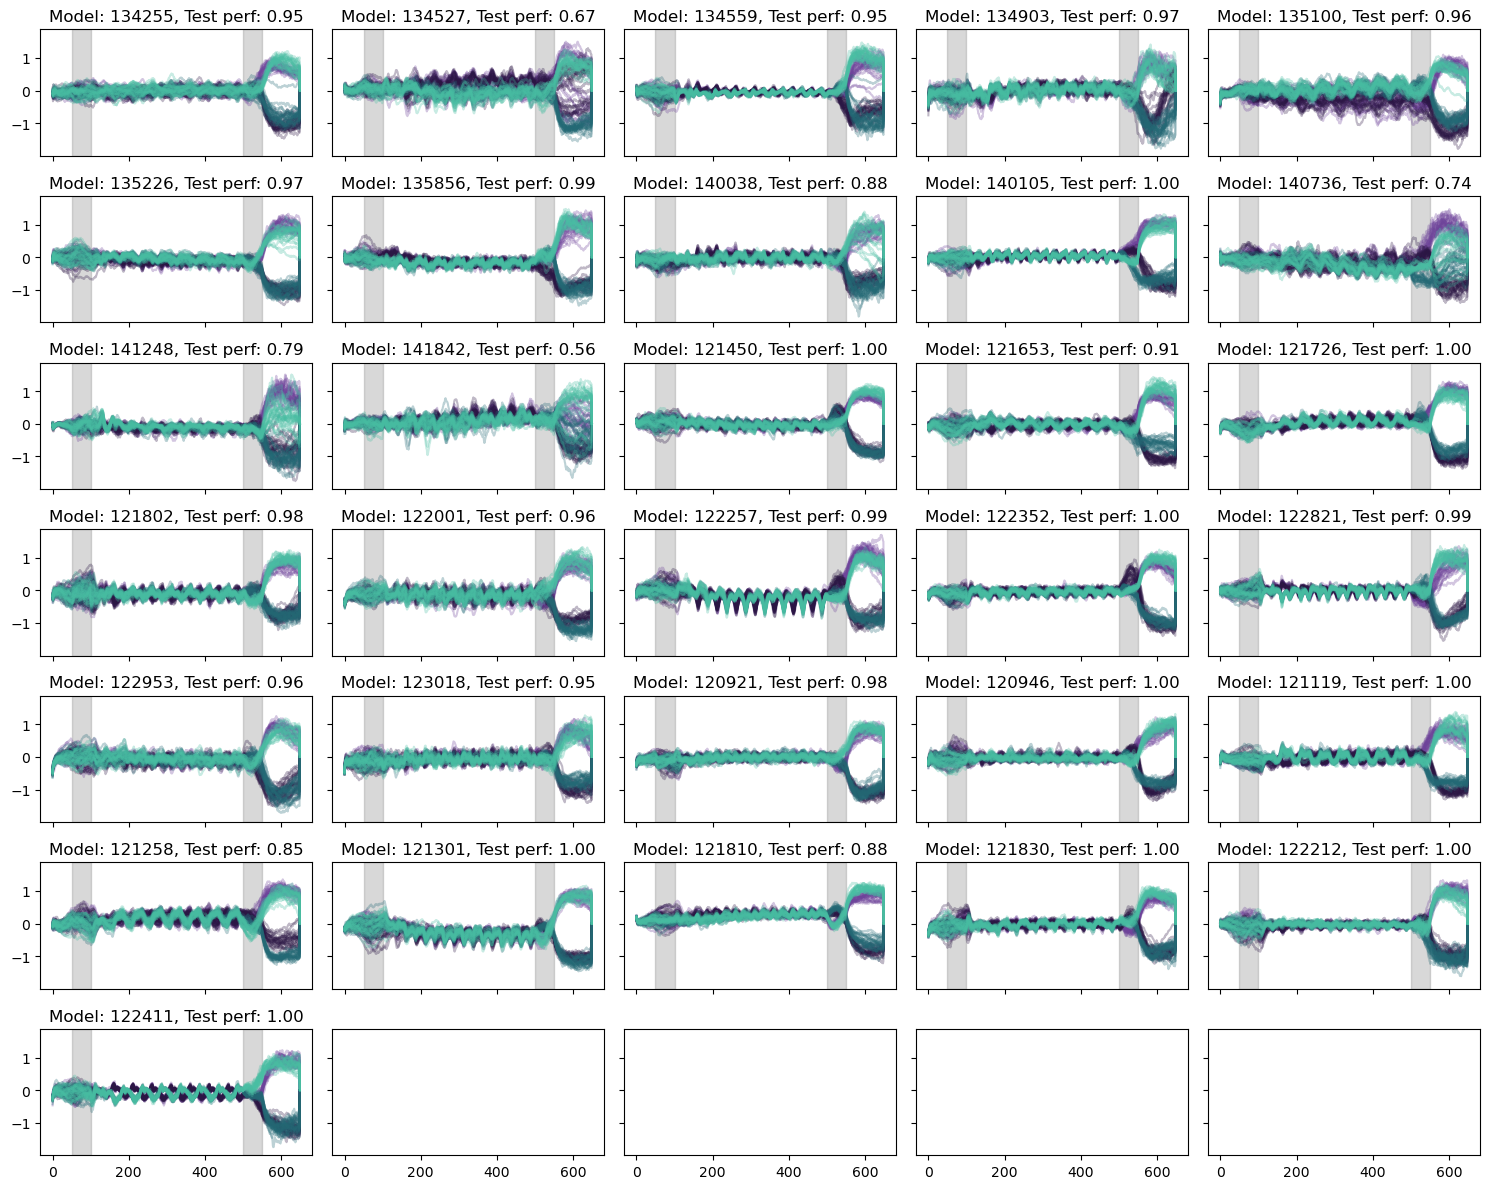

In [ ]:
# plot output for each model

fig, axs = plt.subplots(7,5, figsize=(15,12), sharex=True, sharey=True)
axs = axs.flatten()
test_perfs = []
for i, model_name in enumerate(lfp_model_list):
    output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    with open(os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl'), 'rb') as f:
        settings = pk.load(f)
    
    for n in range(len(bhv_dict['outputs'])):
        axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][0] == 1) * 2 + int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
    axs[i].set_title(f'Model: {model_name[-10:-4]}, Test perf: {np.mean(bhv_dict["perf"]):.2f}')
    test_perfs.append(np.mean(bhv_dict['perf']))
    stim1_on = settings['stim_on']
    stim1_off = stim1_on + settings['stim_dur']
    stim2_on = stim1_off + settings['delay']
    stim2_off = stim2_on + settings['stim_dur']
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

## Some LFP 10Hz data

In [3]:
# jitter models trained with 4Hz LFP input

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0'

lfp4_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '4.0', '.mat'])
lfp10_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '10.0', '.mat'])
# remove directories
lfp4_model_list = [m.split('/')[-1] for m in lfp4_model_list]
lfp4_model_list.sort()
lfp10_model_list = [m.split('/')[-1] for m in lfp10_model_list]
lfp10_model_list.sort()

print(lfp4_model_list)
print(len(lfp4_model_list))
print(lfp10_model_list)
print(len(lfp10_model_list))


['Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135226.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135856.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141842.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726.mat', 'Task_xor

In [3]:
# remove models that did not train properly

import os
for i, model_name in enumerate(lfp10_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs = model_data['eval_perf_mean'][0][0]
    if perfs < 0.95:
        print(f'removing {model_name} with perf {perfs}')
        # os.remove(model_path)

Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_215815.mat, Test perf: 0.99, Train trials: 7001
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_220033.mat, Test perf: 1.0, Train trials: 10501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_221139.mat, Test perf: 0.96, Train trials: 12901
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_221308.mat, Test perf: 0.98, Train trials: 22501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_221955.mat, Test perf: 0.99, Train trials: 19901
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_223354.mat, Test perf: 0.98, Train trials: 22501
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_223914.mat, Test perf: 1.0, Train trials: 19601
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_230334.mat, Test perf: 0.99, Train trials: 32401
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_14_000504.mat, Test perf: 0.97, Train trials: 12401
Model: Task_xor_N_200_

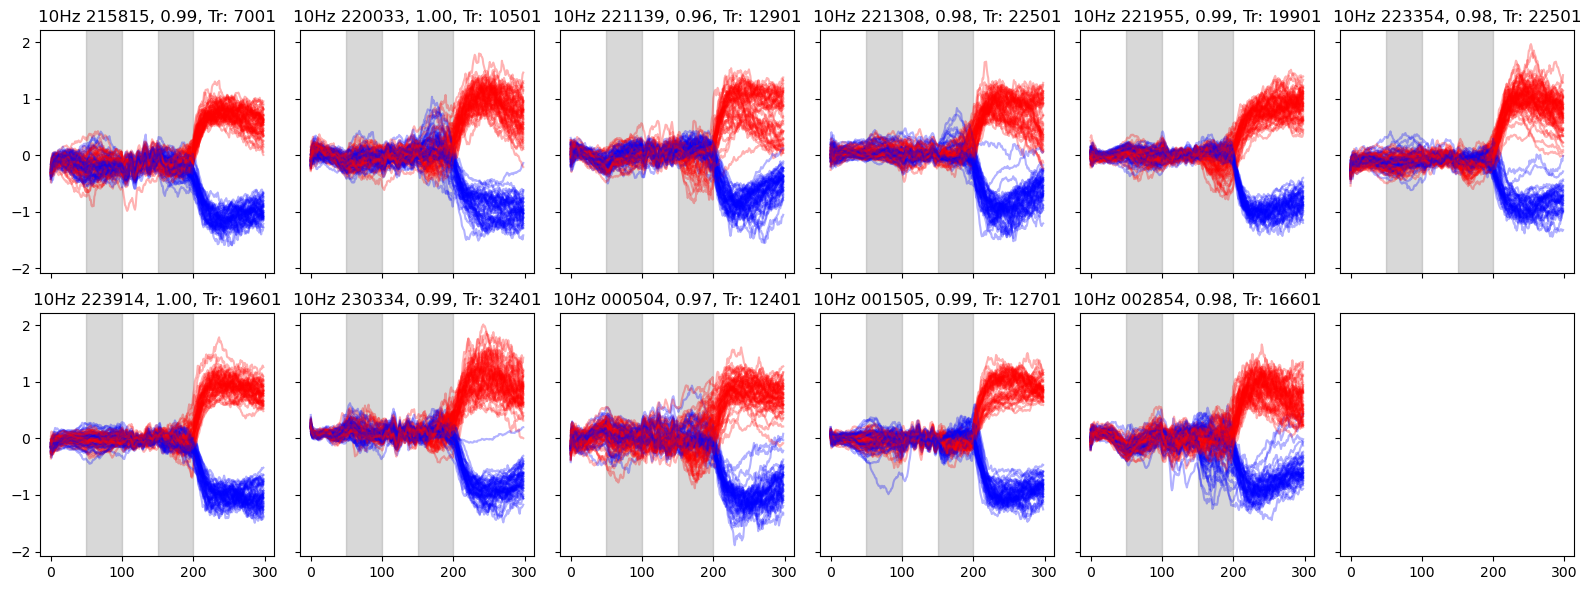

In [9]:
fig, axs = plt.subplots(2, 6, figsize=(16,6), sharex=True, sharey=True)
axs = axs.flatten()

perfs = []
train_trials = []
for i, model_name in enumerate(lfp10_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')
    
    stim1_on = 50
    stim1_off = stim1_on + 50
    stim2_on = stim1_off + 50
    stim2_off = stim2_on + 50

    outs = model_data['eval_os']
    labels = model_data['eval_labels']
    c = ['r' if labels[j]=='same' else 'b' for j in range(len(labels))]
    # c = [0 if labels[j]=='same' else 1 for j in range(len(labels))]
    for j in range(outs.shape[0]):
        axs[i].plot(outs[j].T, color=c[j], alpha=0.3)
    # axs[i].plot(outs.T, color=c, alpha=0.3)
    axs[i].set_title(f'10Hz {model_name[-10:-4]}, {perfs[i]:.2f}, Tr: {train_trials[i]}')
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_LFP_input_phase

Instructions for updating:
non-resource variables are not supported in the long term


In [8]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [4]:
# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [10], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [10]:
n_trials = 25
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp10_model_list

In [12]:
import os
import numpy as np
import pickle as pk
from concurrent.futures import ProcessPoolExecutor

def process_model(model_name):
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    neural_path = os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')
    bhv_path = os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')
    settings_path = os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl')

    if os.path.exists(neural_path) and os.path.exists(bhv_path) and os.path.exists(settings_path):
        print(f"Skipping {model_name}, already saved.")
        return

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for stim1 in stim1s:
        for stim2 in stim2s:
            for _ in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]

                _, r, o, epsp = model.eval_tf(
                    model_dir=os.path.join(model_dir, model_name),
                    settings=settings,
                    u=u,
                    calc_epsp=True
                )

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                if label == 'same':
                    bhv_dict['perf'].append(int(np.max(o[resp_onset:]) > eval_amp_threshold))
                else:
                    bhv_dict['perf'].append(int(np.min(o[resp_onset:]) < -eval_amp_threshold))

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])

    with open(neural_path, 'wb') as f:
        pk.dump(neural_dict, f)
    with open(bhv_path, 'wb') as f:
        pk.dump(bhv_dict, f)
    with open(settings_path, 'wb') as f:
        pk.dump(settings, f)

    print(f"✔ Saved model outputs to {output_dir}")

# ---- MAIN EXEC ----
if __name__ == '__main__':
    n_trials = 25
    eval_amp_threshold = 0.7
    stim1s = [-1, 1]
    stim2s = [-1, 1]
    model_dir = lfp_model_dir
    model_list = lfp10_model_list

    settings = {
        'T': 650,
        'stim_on': 50,
        'stim_dur': 50,
        'delay': 400,
        'DeltaT': 1,
        'taus': 20,
        'lfp_power_target': [10],
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor',
    }

    resp_onset = settings['stim_on'] + 2 * settings['stim_dur'] + settings['delay'] + 10

    with ProcessPoolExecutor() as executor:
        executor.map(process_model, model_list)


✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_223914
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_221139
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_14_002854
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_13_221308
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_LFPdelay_10.0_2025_10_14_000504
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_input_models_wtrain/mod

### make some quick behavior plots

In [3]:
colors = ['#6E439A', '#2B1644', '#236975', '#49BEA3']

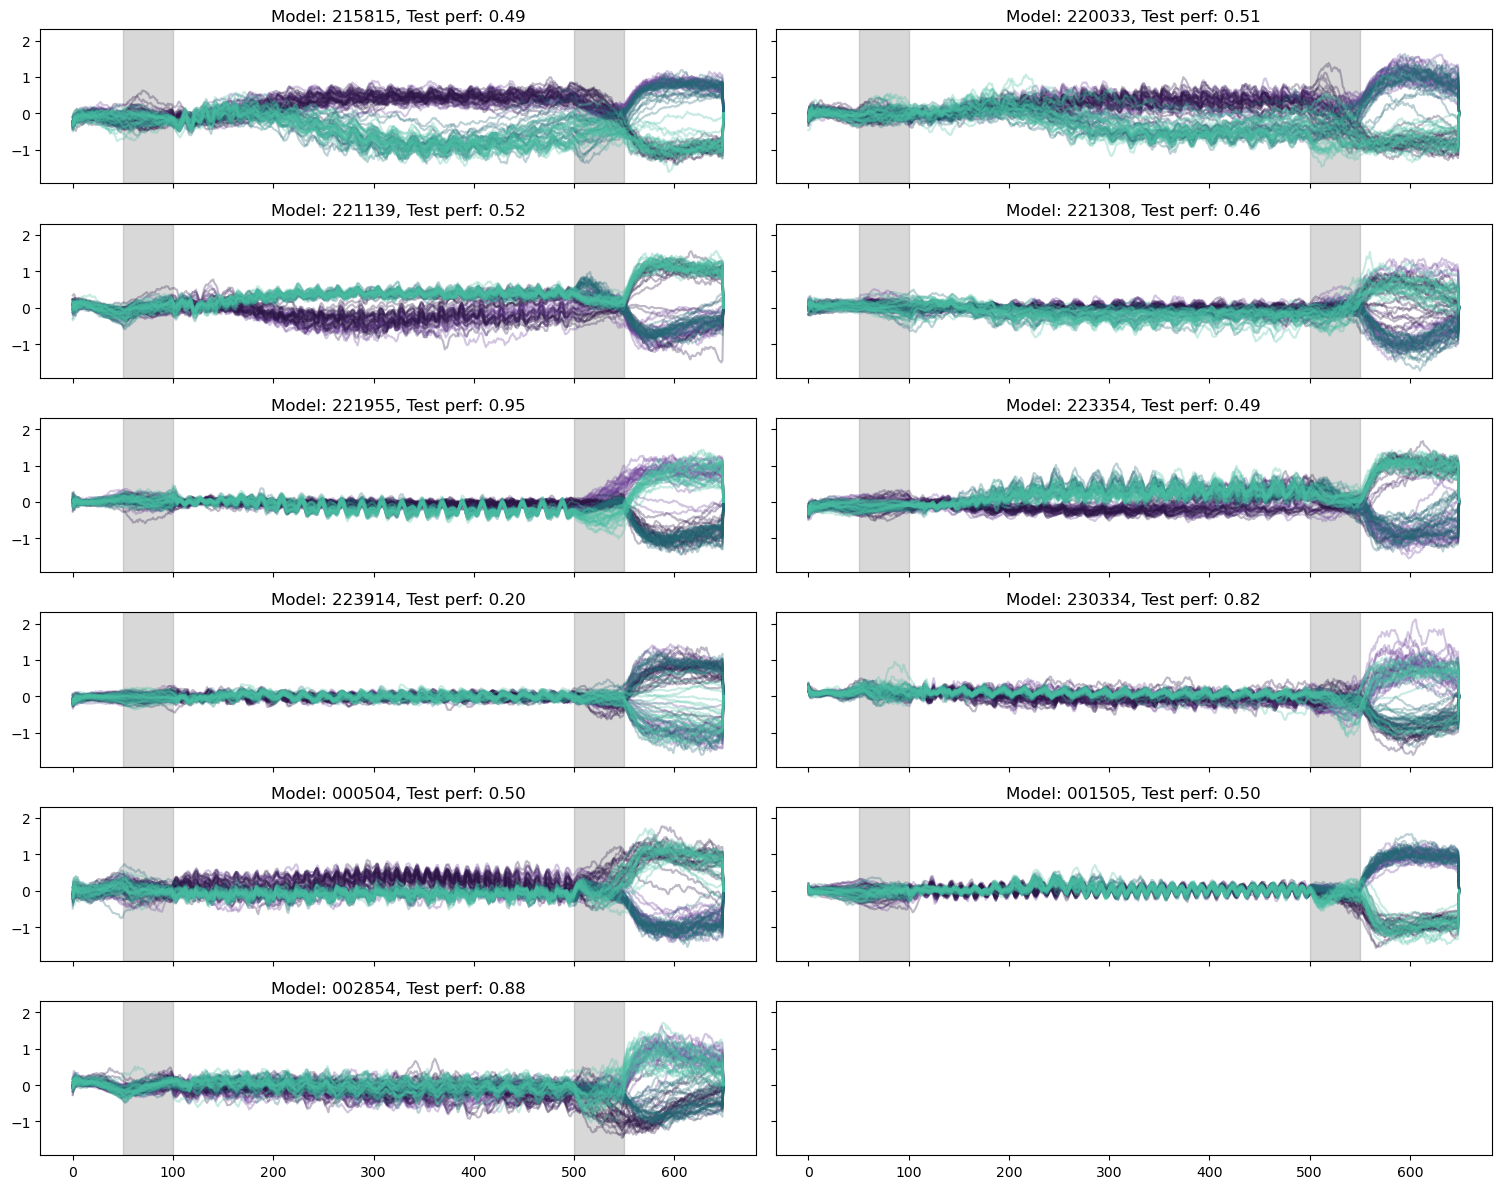

In [7]:
# plot output for each model

fig, axs = plt.subplots(6,2, figsize=(15,12), sharex=True, sharey=True)
axs = axs.flatten()
test_perfs = []
for i, model_name in enumerate(lfp10_model_list):
    output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    with open(os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl'), 'rb') as f:
        settings = pk.load(f)
    
    for n in range(len(bhv_dict['outputs'])):
        axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][0] == 1) * 2 + int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
    axs[i].set_title(f'Model: {model_name[-10:-4]}, Test perf: {np.mean(bhv_dict["perf"]):.2f}')
    test_perfs.append(np.mean(bhv_dict['perf']))
    stim1_on = settings['stim_on']
    stim1_off = stim1_on + settings['stim_dur']
    stim2_on = stim1_off + settings['delay']
    stim2_off = stim2_on + settings['stim_dur']
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

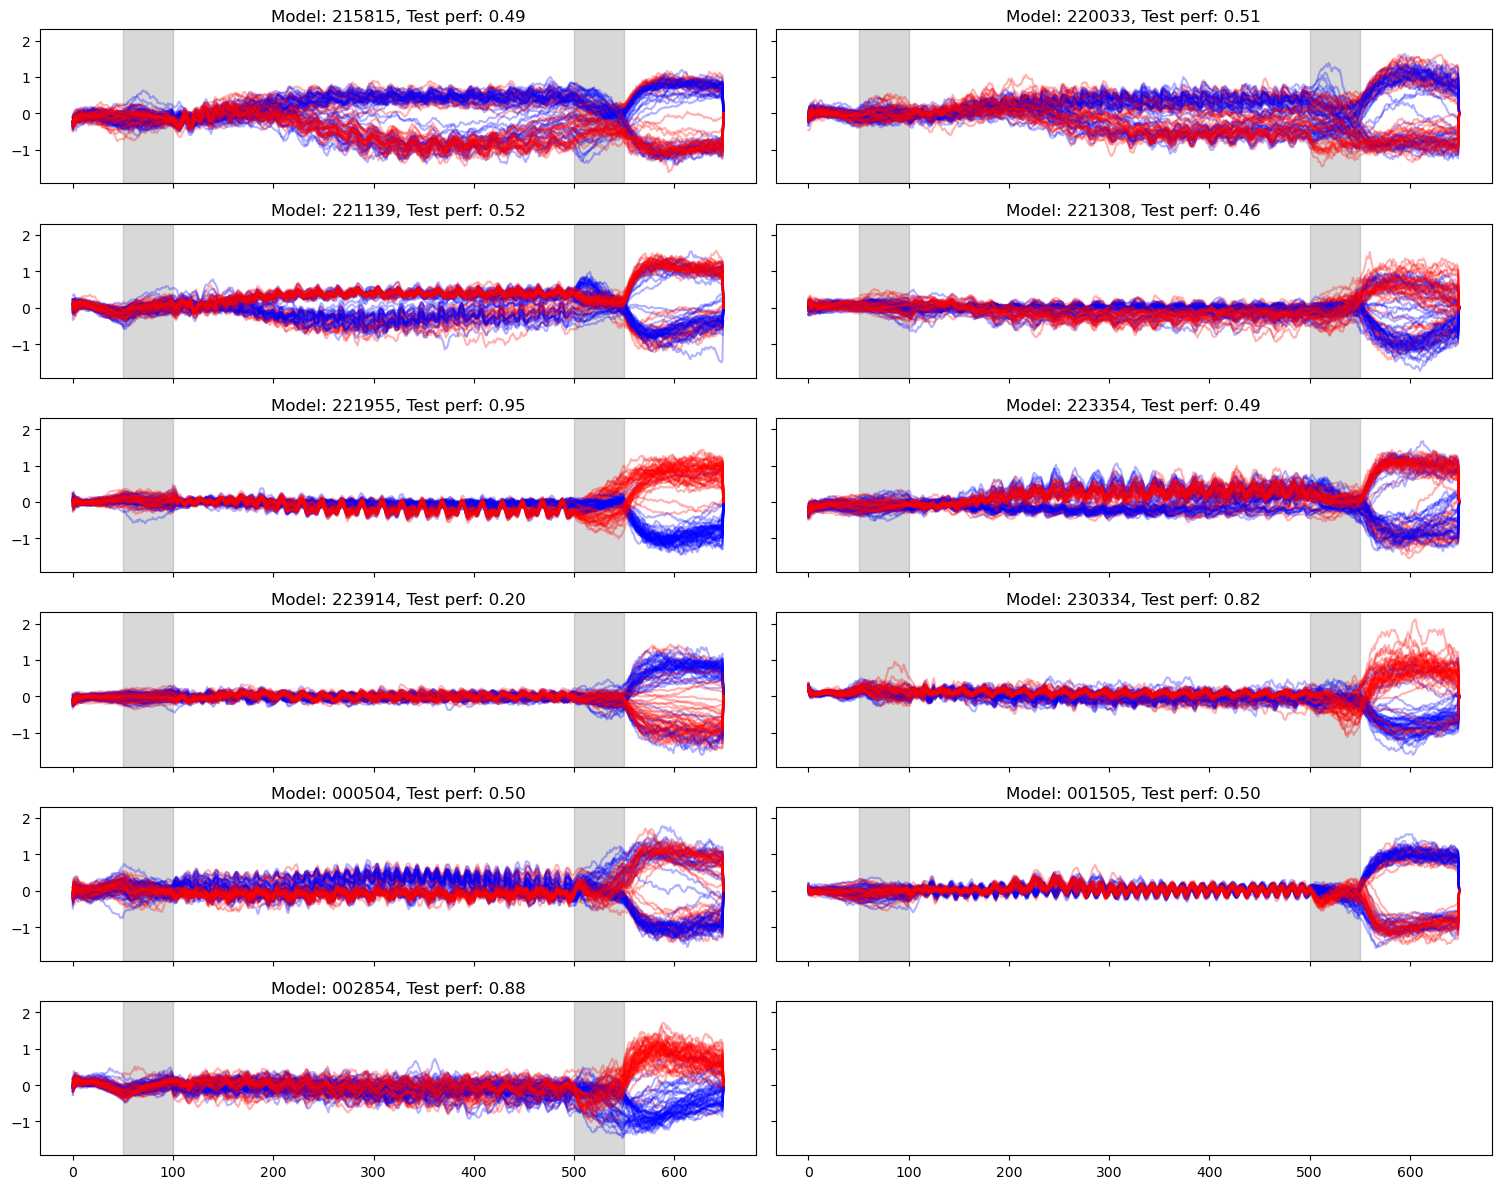

In [5]:
# plot output for each model — in red and blue

fig, axs = plt.subplots(6,2, figsize=(15,12), sharex=True, sharey=True)
axs = axs.flatten()
test_perfs = []
for i, model_name in enumerate(lfp10_model_list):
    output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    with open(os.path.join(output_dir, f'settings_delay{settings["delay"]}.pkl'), 'rb') as f:
        settings = pk.load(f)
    
    for n in range(len(bhv_dict['outputs'])):
        axs[i].plot(bhv_dict['outputs'][n], color='r' if bhv_dict['trial_type'][n][0] == bhv_dict['trial_type'][n][1] else 'b', alpha=0.3)
        # axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][0] == 1) * 2 + int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
    axs[i].set_title(f'Model: {model_name[-10:-4]}, Test perf: {np.mean(bhv_dict["perf"]):.2f}')
    test_perfs.append(np.mean(bhv_dict['perf']))
    stim1_on = settings['stim_on']
    stim1_off = stim1_on + settings['stim_dur']
    stim2_on = stim1_off + settings['delay']
    stim2_off = stim2_on + settings['stim_dur']
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
print(np.mean(test_perfs))
print(np.std(test_perfs))

0.5745454545454545
0.2089960259023487


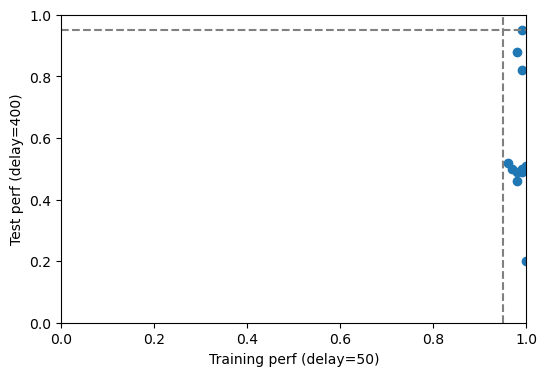

In [10]:
# plot behavior 
plt.figure(figsize=(6,4))
plt.scatter(perfs, test_perfs)
plt.axvline(x=0.95, color='gray', linestyle='--')
plt.axhline(y=0.95, color='gray', linestyle='--')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Training perf (delay=50)')
plt.ylabel('Test perf (delay=400)')
plt.show()


## make input plots

In [2]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_LFP_input_phase

Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [11]:
# 50
settings = {
        'T': 300, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [8], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

In [9]:
u_pos.shape

(3, 300)

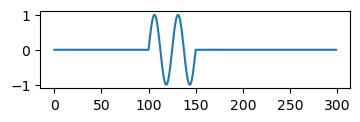

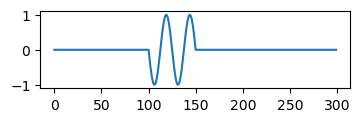

In [14]:
u, label = generate_xor_type(settings, stim1=1, stim2=1)
u_pos = generate_LFP_input_phase(settings, u)
u_neg = generate_LFP_input_phase(settings, -u)

plt.figure(figsize=(4,1))
plt.plot(u_pos[2,:], label='pos')
# save eps
plt.savefig('u_pos.eps')

plt.figure(figsize=(4,1))
plt.plot(u_neg[2,:], label='neg')
# save eps
plt.savefig('u_neg.eps')

# plt.show()